In [1]:
# =========================================
# 1. Imports
# =========================================
from pathlib import Path
import argparse
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway, ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd

BASE_PATH = Path.cwd()
if not (BASE_PATH / "data" / "whodecide" / "processed" / "selects_2023_clean.csv").exists():
    BASE_PATH = BASE_PATH.parent


c:\Users\jmart\Documents\05_Studium\04_Programmierprojekte\04_Semester\DigitalStorytellingAndVisualisation\visualisierungsprojekt\PODSV_Visualisierungsprojekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================================
# 2. CSV-Dateien einlesen
# =========================================

PROCESSED_SELECTS_2023_PATH = BASE_PATH / "data" / "whodecide" / "processed" / "selects_2023_clean.csv"
PROCESSED_SELECTS_2019_PATH = BASE_PATH / "data" / "whodecide" / "processed" / "selects_2019_clean.csv"
PROCESSED_SELECTS_2015_PATH = BASE_PATH / "data" / "whodecide" / "processed" / "selects_2015_clean.csv"

df_2023 = pd.read_csv(PROCESSED_SELECTS_2023_PATH)
df_2019 = pd.read_csv(PROCESSED_SELECTS_2019_PATH)
df_2015 = pd.read_csv(PROCESSED_SELECTS_2015_PATH)  # NEU

df_2023["year"] = 2023
df_2019["year"] = 2019
df_2015["year"] = 2015  # NEU

print(df_2023.shape, df_2019.shape, df_2015.shape)

C:\Users\jmart\AppData\Local\Temp\ipykernel_36924\4067801538.py:9: DtypeWarning: Columns (206,207,208,209,210,211,212,213,214,215) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv(PROCESSED_SELECTS_2023_PATH)


(5033, 309) (6664, 342) (5337, 430)


In [3]:
# Spalten-Check: sind die relevanten Variablen in beiden Datensätzen vorhanden?
cols_needed = ["birthyear", "f11100rec", "f10100", "f11301", "f11302", "f11305"]

for col in cols_needed:
    in_2023 = col in df_2023.columns
    in_2019 = col in df_2019.columns
    in_2015 = col in df_2015.columns  # NEU
    print(f"{col}: 2023={'✓' if in_2023 else '✗'}  2019={'✓' if in_2019 else '✗'}  2015={'✓' if in_2015 else '✗'}")

birthyear: 2023=✓  2019=✓  2015=✓
f11100rec: 2023=✓  2019=✓  2015=✓
f10100: 2023=✓  2019=✓  2015=✓
f11301: 2023=✓  2019=✓  2015=✓
f11302: 2023=✓  2019=✓  2015=✓
f11305: 2023=✓  2019=✓  2015=✓


In [4]:
# =========================================
# 3. Daten vorbereiten
# =========================================

generation_order = [
    "Silent Generation",
    "Baby Boomers",
    "Generation X",
    "Millennials",
    "Generation Z"
]

def assign_generation(year):
    if pd.isna(year):
        return pd.NA
    elif year <= 1945:
        return "Silent Generation"
    elif 1946 <= year <= 1964:
        return "Baby Boomers"
    elif 1965 <= year <= 1980:
        return "Generation X"
    elif 1981 <= year <= 1996:
        return "Millennials"
    else:
        return "Generation Z"

def prepare_df(df):
    df = df.copy()
    df = df[df["f11100rec"] >= 0]
    df["generation"] = df["birthyear"].apply(assign_generation)
    df["voted"] = df["f11100rec"]
    df["political_interest"] = df["f10100"].replace([-99, -98, 9], np.nan)  # 9 NEU
    trust_vars = ["f11301", "f11302", "f11305"]
    df[trust_vars] = df[trust_vars].apply(pd.to_numeric, errors="coerce")
    df[trust_vars] = df[trust_vars].replace([-99, -98], np.nan)
    df["trust_avg"] = df[trust_vars].mean(axis=1)
    df["demo_satisfaction"] = pd.to_numeric(df["f12010"], errors="coerce")
    df["demo_satisfaction"] = df["demo_satisfaction"].replace([-99, -98, 8, 9], np.nan)
    df["demo_satisfaction"] = df["demo_satisfaction"].map({1: 1, 2: 0})
    lr_col = "f12900rec" if "f12900rec" in df.columns else "f12900"
    df["lr_scale"] = pd.to_numeric(df[lr_col], errors="coerce")
    df["lr_scale"] = df["lr_scale"].replace([-99, -98], np.nan)
    df["lr_scale"] = df["lr_scale"] / 10  # 10→1, 110→11
    df["lr_scale"] = df["lr_scale"].where(df["lr_scale"].between(1, 11))
    return df

df_2023 = prepare_df(df_2023)
df_2019 = prepare_df(df_2019)
df_2015 = prepare_df(df_2015)  # NEU

print("2023:", df_2023.shape, "| 2019:", df_2019.shape, "| 2015:", df_2015.shape)


2023: (4984, 315) | 2019: (6610, 348) | 2015: (5282, 436)


# ⚠️ Limitations

- **Generation Z in 2015**: Most members of Generation Z were not yet of voting age in 2015 (voting age in Switzerland: 18). Comparisons involving Generation Z and the year 2015 should therefore be interpreted with caution — the sample is small and not representative.
- **Trust variables (f11301, f11302, f11305)**: The 2015 survey used a different scale than 2019/2023. Trust comparisons are therefore limited to 2019 vs 2023 only.
- **Data source**: SELECTS Post-Election Survey (PES), waves 2015, 2019, 2023.

# Chart 1: Voter Turnout

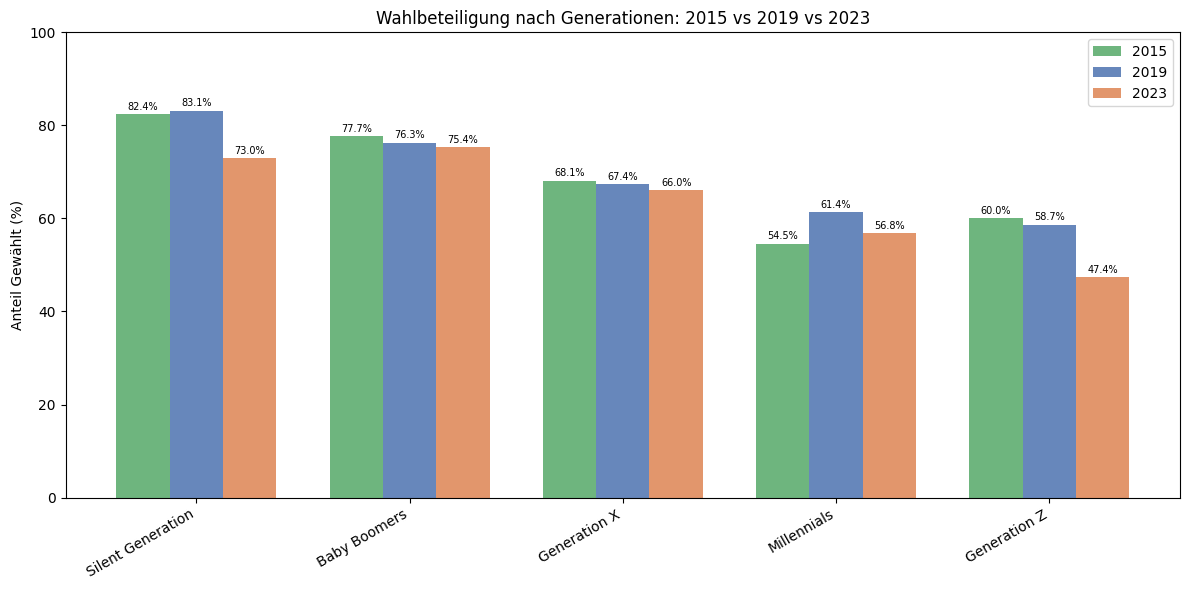

In [5]:
# =========================================
# Chart 1: Wahlbeteiligung 2015 vs 2019 vs 2023
# =========================================

turnout_2015 = df_2015.groupby("generation")["voted"].mean().reindex(generation_order) * 100
turnout_2019 = df_2019.groupby("generation")["voted"].mean().reindex(generation_order) * 100
turnout_2023 = df_2023.groupby("generation")["voted"].mean().reindex(generation_order) * 100

x = np.arange(len(generation_order))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars_2015 = ax.bar(x - width, turnout_2015, width, label="2015", color="#55A868", alpha=0.85)
bars_2019 = ax.bar(x,         turnout_2019, width, label="2019", color="#4C72B0", alpha=0.85)
bars_2023 = ax.bar(x + width, turnout_2023, width, label="2023", color="#DD8452", alpha=0.85)

for bars, vals in [(bars_2015, turnout_2015), (bars_2019, turnout_2019), (bars_2023, turnout_2023)]:
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=7)

ax.set_title("Wahlbeteiligung nach Generationen: 2015 vs 2019 vs 2023")
ax.set_ylabel("Anteil Gewählt (%)")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(generation_order, rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

In [6]:
# =========================================
# Chart 1: Statistischer Test — Chi² + Cramér's V + Paarweise Tests
# =========================================
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(contingency_table):
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.values.sum()
    k = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * k))

pairs = [("2015", df_2015), ("2019", df_2019), ("2023", df_2023)]

for gen in generation_order:
    print(f"\n{'='*55}")
    print(f"  {gen}")
    print(f"{'='*55}")

    # Gesamt Chi² + Cramér's V (alle drei Jahre)
    groups = {year: df[df["generation"] == gen]["voted"].reset_index(drop=True)
              for year, df in pairs}

    contingency_all = pd.crosstab(
        pd.concat(list(groups.values())).reset_index(drop=True),
        pd.concat([pd.Series([y] * len(g)) for y, g in groups.items()]).reset_index(drop=True)
    )

    chi2, p, _, _ = chi2_contingency(contingency_all)
    v = cramers_v(contingency_all)
    sig = "✓ signifikant" if p < 0.05 else "✗ nicht signifikant"
    print(f"  Gesamt:        chi2={chi2:.2f}  p={p:.3f}  V={v:.3f}  {sig}")

    # Paarweise Tests
    pair_combos = [("2015", df_2015, "2019", df_2019),
                   ("2015", df_2015, "2023", df_2023),
                   ("2019", df_2019, "2023", df_2023)]

    for y1, d1, y2, d2 in pair_combos:
        g1 = d1[d1["generation"] == gen]["voted"].reset_index(drop=True)
        g2 = d2[d2["generation"] == gen]["voted"].reset_index(drop=True)

        contingency = pd.crosstab(
            pd.concat([g1, g2]).reset_index(drop=True),
            pd.concat([pd.Series([y1] * len(g1)),
                       pd.Series([y2] * len(g2))]).reset_index(drop=True)
        )

        chi2, p, _, _ = chi2_contingency(contingency)
        v = cramers_v(contingency)
        sig = "✓" if p < 0.05 else "✗"
        print(f"  {y1} vs {y2}:  chi2={chi2:.2f}  p={p:.3f}  V={v:.3f}  {sig}")


  Silent Generation
  Gesamt:        chi2=18.73  p=0.000  V=0.098  ✓ signifikant
  2015 vs 2019:  chi2=0.09  p=0.762  V=0.008  ✗
  2015 vs 2023:  chi2=13.76  p=0.000  V=0.105  ✓
  2019 vs 2023:  chi2=14.82  p=0.000  V=0.118  ✓

  Baby Boomers
  Gesamt:        chi2=2.55  p=0.280  V=0.021  ✗ nicht signifikant
  2015 vs 2019:  chi2=0.95  p=0.330  V=0.015  ✗
  2015 vs 2023:  chi2=2.38  p=0.123  V=0.027  ✗
  2019 vs 2023:  chi2=0.42  p=0.516  V=0.010  ✗

  Generation X
  Gesamt:        chi2=1.45  p=0.485  V=0.018  ✗ nicht signifikant
  2015 vs 2019:  chi2=0.15  p=0.702  V=0.007  ✗
  2015 vs 2023:  chi2=1.28  p=0.258  V=0.022  ✗
  2019 vs 2023:  chi2=0.66  p=0.418  V=0.014  ✗

  Millennials
  Gesamt:        chi2=13.34  p=0.001  V=0.059  ✓ signifikant
  2015 vs 2019:  chi2=12.55  p=0.000  V=0.068  ✓
  2015 vs 2023:  chi2=1.13  p=0.287  V=0.022  ✗
  2019 vs 2023:  chi2=5.19  p=0.023  V=0.046  ✓

  Generation Z
  Gesamt:        chi2=13.66  p=0.001  V=0.116  ✓ signifikant
  2015 vs 2019:  chi2=

## Findings: Voter Turnout

### Method
Comparison of voter turnout across three election years (2015, 2019, 2023) using **Chi²-test** and **Cramér's V** (effect size), broken down by generation.

---

### Results

#### Silent Generation
- No difference 2015→2019 (p=0.762, V=0.008)
- Significant decline 2019→2023 (p=0.000, V=0.118)
- 👉 Likely driven by demographic factors (age, health)

#### Baby Boomers & Generation X
- No significant differences across all years
- Effects close to zero (V < 0.03)
- 👉 Stable, consistent voter turnout

#### Millennials
- No difference 2015→2019 (p=0.101, V=0.032)
- Significant decline 2015→2023 and 2019→2023
- 👉 Decline is a recent phenomenon

#### Generation Z
- No difference 2015→2019 (p=0.901, V=0.006) — ⚠️ see Limitations
- Significant decline from 2023 (p=0.001, V=0.110)
- 👉 Drop only visible in the most recent survey

---

### Interpretation
The middle generations (Baby Boomers, Generation X) remain stable over the years.
At both ends, however, changes are visible:
- **Silent Generation**: Decline likely due to demographic factors
- **Millennials & Generation Z**: Recent decline — possible link to declining trust in institutions (→ see Chart 3)

# Chart 2: Political Interest

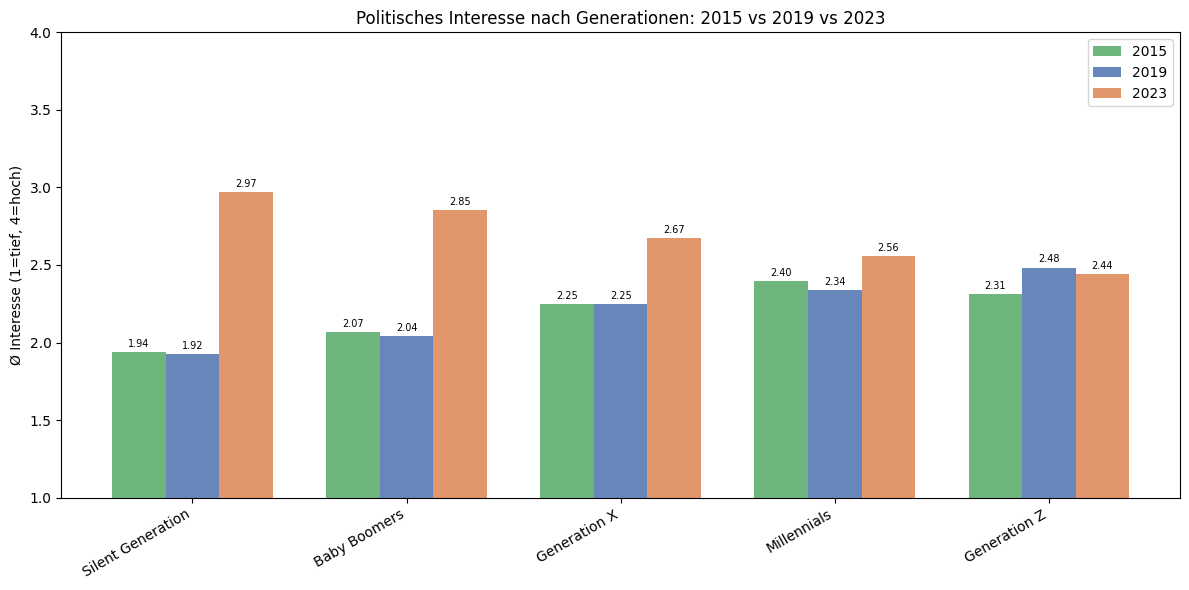

In [7]:
# =========================================
# Chart 2: Politisches Interesse 2015 vs 2019 vs 2023
# =========================================

interest_2015 = df_2015.groupby("generation")["political_interest"].mean().reindex(generation_order)
interest_2019 = df_2019.groupby("generation")["political_interest"].mean().reindex(generation_order)
interest_2023 = df_2023.groupby("generation")["political_interest"].mean().reindex(generation_order)

x = np.arange(len(generation_order))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars_2015 = ax.bar(x - width, interest_2015, width, label="2015", color="#55A868", alpha=0.85)
bars_2019 = ax.bar(x,         interest_2019, width, label="2019", color="#4C72B0", alpha=0.85)
bars_2023 = ax.bar(x + width, interest_2023, width, label="2023", color="#DD8452", alpha=0.85)

for bars, vals in [(bars_2015, interest_2015), (bars_2019, interest_2019), (bars_2023, interest_2023)]:
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_title("Politisches Interesse nach Generationen: 2015 vs 2019 vs 2023")
ax.set_ylabel("Ø Interesse (1=tief, 4=hoch)")
ax.set_ylim(1, 4)
ax.set_xticks(x)
ax.set_xticklabels(generation_order, rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

In [8]:
# =========================================
# Chart 2: Statistischer Test — ANOVA + Tukey-HSD
# =========================================

pairs = [("2015", df_2015), ("2019", df_2019), ("2023", df_2023)]

for gen in generation_order:
    print(f"\n{'='*55}")
    print(f"  {gen}")
    print(f"{'='*55}")

    # Gesamt ANOVA
    groups = [df[df["generation"] == gen]["political_interest"].dropna()
              for _, df in pairs]
    f_stat, p = f_oneway(*groups)
    sig = "✓ signifikant" if p < 0.05 else "✗ nicht signifikant"
    print(f"  ANOVA:  F={f_stat:.2f}  p={p:.3f}  {sig}")

    # Tukey-HSD
    df_tukey = pd.concat([
        df[df["generation"] == gen][["political_interest"]].assign(year=year)
        for year, df in pairs
    ]).dropna()

    tukey = pairwise_tukeyhsd(
        endog=df_tukey["political_interest"],
        groups=df_tukey["year"],
        alpha=0.05
    )
    print(tukey.summary())


  Silent Generation
  ANOVA:  F=288.94  p=0.000  ✓ signifikant
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  2015   2019  -0.0145 0.9242 -0.1045 0.0755  False
  2015   2023   1.0289    0.0  0.9202 1.1377   True
  2019   2023   1.0434    0.0  0.9308 1.1561   True
---------------------------------------------------

  Baby Boomers
  ANOVA:  F=600.66  p=0.000  ✓ signifikant
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  2015   2019   -0.025 0.5777 -0.0838 0.0337  False
  2015   2023   0.7851    0.0  0.7215 0.8486   True
  2019   2023   0.8101    0.0  0.7504 0.8699   True
---------------------------------------------------

  Generation X
  ANOVA:  F=139.85  p=0.000  ✓ signifikant
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  up

## Findings: Political Interest

### Method
ANOVA + Tukey-HSD test across three years (2015, 2019, 2023), broken down by generation.

---

### Results

- **Silent Generation to Millennials**: No difference 2015→2019, strong increase 2019→2023
- **Generation Z**: No significant trend across the years

---

### Interpretation
Political interest has risen significantly since 2019 — yet voter turnout among Millennials and Generation Z is declining.

👉 **Interest alone does not explain political participation. Trust in institutions may be the decisive factor** (→ Chart 3).

# Chart 3: Institutional Trust & Democratic Satisfaction

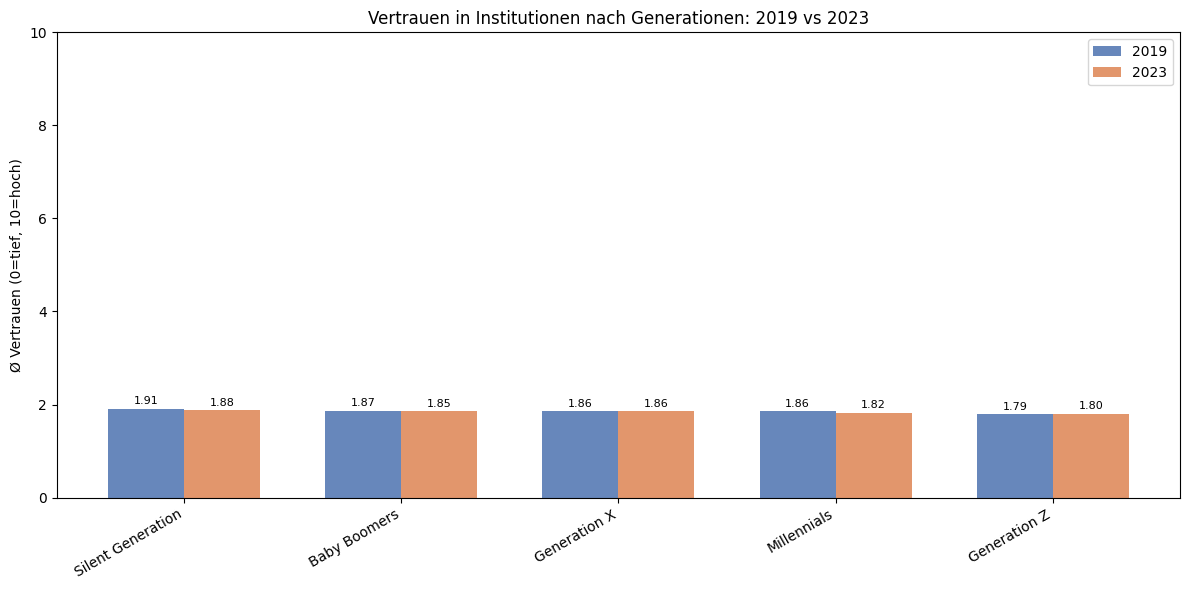

In [9]:
# =========================================
# Chart 3: Vertrauen in Institutionen 2019 vs 2023
# =========================================

trust_2019 = df_2019.groupby("generation")["trust_avg"].mean().reindex(generation_order)
trust_2023 = df_2023.groupby("generation")["trust_avg"].mean().reindex(generation_order)

x = np.arange(len(generation_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_2019 = ax.bar(x - width/2, trust_2019, width, label="2019", color="#4C72B0", alpha=0.85)
bars_2023 = ax.bar(x + width/2, trust_2023, width, label="2023", color="#DD8452", alpha=0.85)

for bars, vals in [(bars_2019, trust_2019), (bars_2023, trust_2023)]:
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_title("Vertrauen in Institutionen nach Generationen: 2019 vs 2023")
ax.set_ylabel("Ø Vertrauen (0=tief, 10=hoch)")
ax.set_ylim(0, 10)
ax.set_xticks(x)
ax.set_xticklabels(generation_order, rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

In [10]:
# =========================================
# Chart 3: Statistischer Test — ANOVA + Tukey-HSD
# =========================================

pairs_trust = [("2019", df_2019), ("2023", df_2023)]

for gen in generation_order:
    print(f"\n{'='*55}")
    print(f"  {gen}")
    print(f"{'='*55}")

    groups = [df[df["generation"] == gen]["trust_avg"].dropna()
              for _, df in pairs_trust]
    f_stat, p = f_oneway(*groups)
    sig = "✓ signifikant" if p < 0.05 else "✗ nicht signifikant"
    print(f"  ANOVA:  F={f_stat:.2f}  p={p:.3f}  {sig}")

    df_tukey = pd.concat([
        df[df["generation"] == gen][["trust_avg"]].assign(year=year)
        for year, df in pairs_trust
    ]).dropna()

    tukey = pairwise_tukeyhsd(
        endog=df_tukey["trust_avg"],
        groups=df_tukey["year"],
        alpha=0.05
    )
    print(tukey.summary())


  Silent Generation
  ANOVA:  F=1.90  p=0.170  ✗ nicht signifikant
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  2019   2023  -0.0295 0.1696 -0.0718 0.0127  False
---------------------------------------------------

  Baby Boomers
  ANOVA:  F=2.22  p=0.136  ✗ nicht signifikant
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  2019   2023  -0.0172 0.1362 -0.0397 0.0054  False
---------------------------------------------------

  Generation X
  ANOVA:  F=0.14  p=0.704  ✗ nicht signifikant
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
  2019   2023  -0.0042 0.704 -0.026 0.0176  False
-------------------------------------------------

  Millennials
  ANOVA:  F=8.06  p

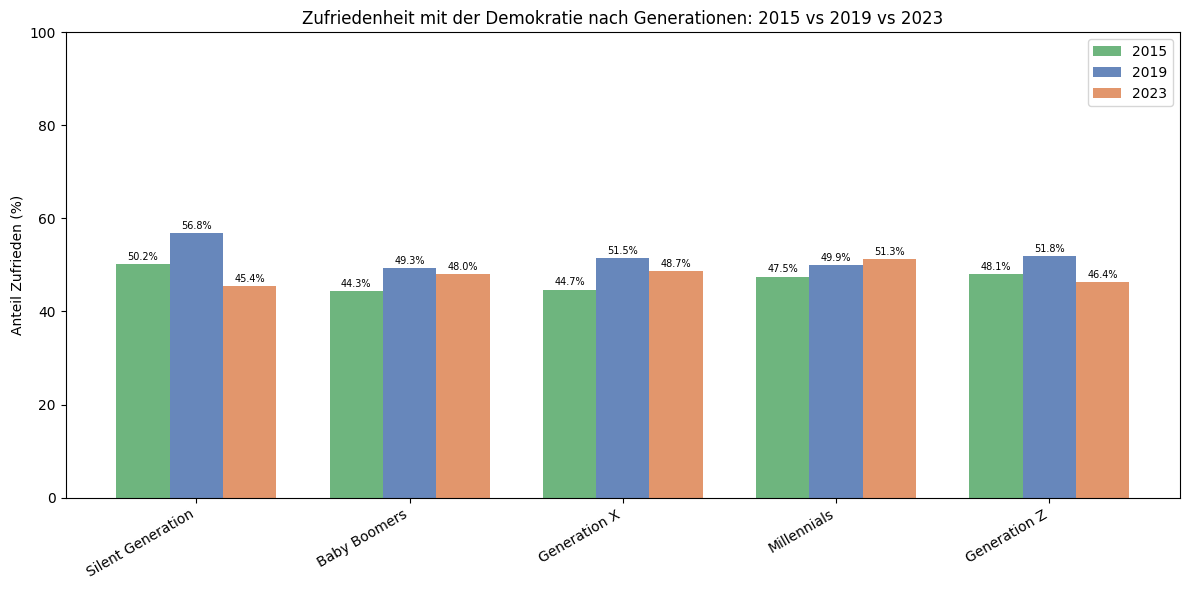

In [11]:
# =========================================
# Chart 3b: Demokratiezufriedenheit 2015 vs 2019 vs 2023
# =========================================

demo_2015 = df_2015.groupby("generation")["demo_satisfaction"].mean().reindex(generation_order) * 100
demo_2019 = df_2019.groupby("generation")["demo_satisfaction"].mean().reindex(generation_order) * 100
demo_2023 = df_2023.groupby("generation")["demo_satisfaction"].mean().reindex(generation_order) * 100

x = np.arange(len(generation_order))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars_2015 = ax.bar(x - width, demo_2015, width, label="2015", color="#55A868", alpha=0.85)
bars_2019 = ax.bar(x,         demo_2019, width, label="2019", color="#4C72B0", alpha=0.85)
bars_2023 = ax.bar(x + width, demo_2023, width, label="2023", color="#DD8452", alpha=0.85)

for bars, vals in [(bars_2015, demo_2015), (bars_2019, demo_2019), (bars_2023, demo_2023)]:
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=7)

ax.set_title("Zufriedenheit mit der Demokratie nach Generationen: 2015 vs 2019 vs 2023")
ax.set_ylabel("Anteil Zufrieden (%)")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels(generation_order, rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
# =========================================
# Chart 3b: Statistischer Test — Chi² + Cramér's V
# =========================================

pairs_demo = [("2015", df_2015), ("2019", df_2019), ("2023", df_2023)]
pair_combos = [("2015", df_2015, "2019", df_2019),
               ("2015", df_2015, "2023", df_2023),
               ("2019", df_2019, "2023", df_2023)]

for gen in generation_order:
    print(f"\n{'='*55}")
    print(f"  {gen}")
    print(f"{'='*55}")

    groups = {year: df[df["generation"] == gen]["demo_satisfaction"].reset_index(drop=True)
              for year, df in pairs_demo}

    contingency_all = pd.crosstab(
        pd.concat(list(groups.values())).reset_index(drop=True),
        pd.concat([pd.Series([y] * len(g)) for y, g in groups.items()]).reset_index(drop=True)
    )

    chi2, p, _, _ = chi2_contingency(contingency_all)
    v = cramers_v(contingency_all)
    sig = "✓ signifikant" if p < 0.05 else "✗ nicht signifikant"
    print(f"  Gesamt:        chi2={chi2:.2f}  p={p:.3f}  V={v:.3f}  {sig}")

    for y1, d1, y2, d2 in pair_combos:
        g1 = d1[d1["generation"] == gen]["demo_satisfaction"].reset_index(drop=True)
        g2 = d2[d2["generation"] == gen]["demo_satisfaction"].reset_index(drop=True)

        contingency = pd.crosstab(
            pd.concat([g1, g2]).reset_index(drop=True),
            pd.concat([pd.Series([y1] * len(g1)),
                       pd.Series([y2] * len(g2))]).reset_index(drop=True)
        )

        chi2, p, _, _ = chi2_contingency(contingency)
        v = cramers_v(contingency)
        sig = "✓" if p < 0.05 else "✗"
        print(f"  {y1} vs {y2}:  chi2={chi2:.2f}  p={p:.3f}  V={v:.3f}  {sig}")


  Silent Generation
  Gesamt:        chi2=9.77  p=0.008  V=0.084  ✓ signifikant
  2015 vs 2019:  chi2=4.75  p=0.029  V=0.064  ✓
  2015 vs 2023:  chi2=1.37  p=0.241  V=0.040  ✗
  2019 vs 2023:  chi2=7.95  p=0.005  V=0.101  ✓

  Baby Boomers
  Gesamt:        chi2=6.84  p=0.033  V=0.043  ✓ signifikant
  2015 vs 2019:  chi2=6.43  p=0.011  V=0.049  ✓
  2015 vs 2023:  chi2=2.93  p=0.087  V=0.036  ✗
  2019 vs 2023:  chi2=0.37  p=0.542  V=0.012  ✗

  Generation X
  Gesamt:        chi2=8.96  p=0.011  V=0.057  ✓ signifikant
  2015 vs 2019:  chi2=8.68  p=0.003  V=0.066  ✓
  2015 vs 2023:  chi2=2.41  p=0.120  V=0.039  ✗
  2019 vs 2023:  chi2=1.43  p=0.232  V=0.027  ✗

  Millennials
  Gesamt:        chi2=1.81  p=0.406  V=0.030  ✗ nicht signifikant
  2015 vs 2019:  chi2=0.77  p=0.379  V=0.023  ✗
  2015 vs 2023:  chi2=1.56  p=0.211  V=0.036  ✗
  2019 vs 2023:  chi2=0.18  p=0.670  V=0.012  ✗

  Generation Z
  Gesamt:        chi2=1.33  p=0.514  V=0.052  ✗ nicht signifikant
  2015 vs 2019:  chi2=0.11  

## Findings: Institutional Trust & Democratic Satisfaction

### Method
- **Trust** (f11301, f11302, f11305): Average across parliament, government, and parties (scale 0–10). Only 2019 vs 2023, as the 2015 survey used a different scale (→ see Limitations).
- **Democratic satisfaction** (f12010): Share of satisfied respondents (1=satisfied, 2=dissatisfied). Comparable across all three years. Chi² + Cramér's V.

---

### Results

#### Institutional Trust (2019 vs 2023)
- No significant differences for any generation
- 👉 Trust has remained stable across all generations

#### Democratic Satisfaction (2015 vs 2019 vs 2023)
- **Silent Generation, Baby Boomers, Generation X**: Significant decline 2015→2019, stable afterwards
- **Millennials & Generation Z**: No significant trend — consistently more sceptical

---

### Interpretation
Together with Charts 1 and 2, the following picture emerges:

| | Millennials & Gen Z |
|---|---|
| Political interest | ↑ increased (2019→2023) |
| Institutional trust | → stable |
| Democratic satisfaction | → stable (consistently low) |
| Voter turnout | ↓ declined |

👉 **None of the measured factors fully explains the decline in voter turnout.**
Another factor may be decisive — e.g. political alienation or the feeling that voting makes no difference (→ possible follow-up using f12301).

# Chart 4: Political Orientation (Left–Right)

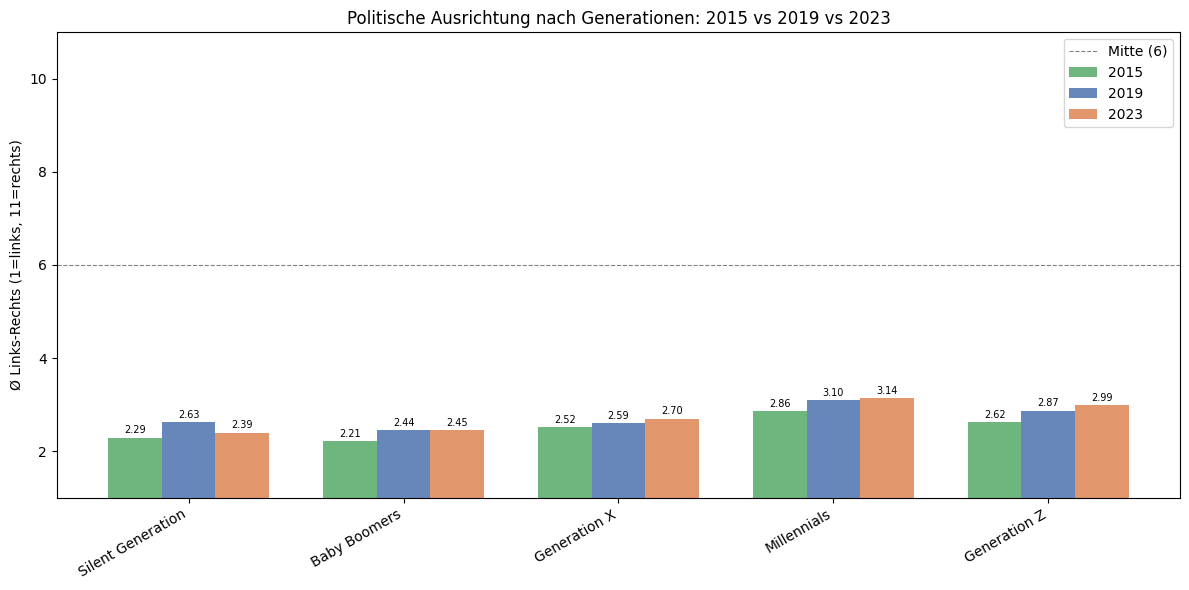

In [13]:
# =========================================
# Chart 4: Politische Ausrichtung 2015 vs 2019 vs 2023
# =========================================

lr_2015 = df_2015.groupby("generation")["lr_scale"].mean().reindex(generation_order)
lr_2019 = df_2019.groupby("generation")["lr_scale"].mean().reindex(generation_order)
lr_2023 = df_2023.groupby("generation")["lr_scale"].mean().reindex(generation_order)

x = np.arange(len(generation_order))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars_2015 = ax.bar(x - width, lr_2015, width, label="2015", color="#55A868", alpha=0.85)
bars_2019 = ax.bar(x,         lr_2019, width, label="2019", color="#4C72B0", alpha=0.85)
bars_2023 = ax.bar(x + width, lr_2023, width, label="2023", color="#DD8452", alpha=0.85)

for bars, vals in [(bars_2015, lr_2015), (bars_2019, lr_2019), (bars_2023, lr_2023)]:
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7)

# Mittellinie bei 6 (Mitte der Skala 1–11)
ax.axhline(y=6, color="grey", linestyle="--", linewidth=0.8, label="Mitte (6)")

ax.set_title("Politische Ausrichtung nach Generationen: 2015 vs 2019 vs 2023")
ax.set_ylabel("Ø Links-Rechts (1=links, 11=rechts)")
ax.set_ylim(1, 11)
ax.set_xticks(x)
ax.set_xticklabels(generation_order, rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

In [14]:
# =========================================
# Chart 4: Statistischer Test — ANOVA + Tukey-HSD
# =========================================

pairs_lr = [("2015", df_2015), ("2019", df_2019), ("2023", df_2023)]

for gen in generation_order:
    print(f"\n{'='*55}")
    print(f"  {gen}")
    print(f"{'='*55}")

    groups = [df[df["generation"] == gen]["lr_scale"].dropna()
              for _, df in pairs_lr]
    f_stat, p = f_oneway(*groups)
    sig = "✓ signifikant" if p < 0.05 else "✗ nicht signifikant"
    print(f"  ANOVA:  F={f_stat:.2f}  p={p:.3f}  {sig}")

    df_tukey = pd.concat([
        df[df["generation"] == gen][["lr_scale"]].assign(year=year)
        for year, df in pairs_lr
    ]).dropna()

    tukey = pairwise_tukeyhsd(
        endog=df_tukey["lr_scale"],
        groups=df_tukey["year"],
        alpha=0.05
    )
    print(tukey.summary())


  Silent Generation
  ANOVA:  F=3.76  p=0.024  ✓ signifikant
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  2015   2019   0.3356 0.0178  0.0469 0.6244   True
  2015   2023   0.1026 0.7755 -0.2518  0.457  False
  2019   2023   -0.233 0.3068 -0.6056 0.1395  False
---------------------------------------------------

  Baby Boomers
  ANOVA:  F=7.27  p=0.001  ✓ signifikant
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  2015   2019   0.2299 0.0023  0.0695 0.3903   True
  2015   2023   0.2375 0.0034   0.066  0.409   True
  2019   2023   0.0076 0.9937 -0.1582 0.1733  False
---------------------------------------------------

  Generation X
  ANOVA:  F=1.82  p=0.162  ✗ nicht signifikant
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  

## Findings: Political Orientation

### Method
ANOVA + Tukey-HSD test across three years (2015, 2019, 2023), broken down by generation.
Scale 1=left to 11=right, midpoint at 6.

---

### Results

#### Silent Generation
- Significant rightward shift 2015→2019 (p=0.018)
- Stable afterwards — shift did not intensify further

#### Baby Boomers
- Significant rightward shift 2015→2019 and 2015→2023
- Stable 2019→2023 — shift has consolidated
- 👉 Strongest and most consistent effect across all generations

#### Generation X
- No significant differences across the years
- 👉 Politically stable generation

#### Millennials
- Significant rightward shift 2015→2023 (p=0.035)
- 2015→2019 and 2019→2023 not significant — slow, gradual shift
- 👉 Similar pattern to older generations, but weaker effect

#### Generation Z
- No significant differences across the years — ⚠️ see Limitations

---

### Interpretation
Silent Generation, Baby Boomers, and Millennials have shifted slightly to the right between 2015 and 2023. Generation X and Z remain stable.

👉 **Combined with declining voter turnout among Millennials and Gen Z, this may mean: younger people vote less, while older — and increasingly right-leaning — generations dominate political decisions.**

# Who Decides? — Project Roadmap

## Goal
Examine how political participation differs between generations and which factors explain these differences.
Data: SELECTS Post-Election Survey (PES), waves 2015, 2019, 2023.

---

## 1. Voter Turnout ✓
- Younger generations (Millennials, Gen Z) vote significantly less since 2019
- Older generations stable — except Silent Generation (decline 2019→2023)
- Baby Boomers and Generation X consistently high

---

## 2. Political Interest ✓
- Strong increase 2019→2023 for almost all generations
- Generation Z shows no clear trend
- 👉 Interest is rising, but turnout is falling — a paradox!

---

## 3. Institutional Trust & Democratic Satisfaction ✓
- Institutional trust: stable across all generations (2019 vs 2023 only)
- Democratic satisfaction: decline 2015→2019 among older generations, recovery afterwards
- Millennials & Gen Z consistently more sceptical
- 👉 Neither trust nor interest fully explains the decline

---

## 4. Political Orientation ✓
- Silent Generation, Baby Boomers, Millennials: slight rightward shift
- Generation X and Z: stable
- 👉 Older generations vote more and lean increasingly right — younger vote less

---

## Overall Story
1. Younger generations vote less — even though their interest has increased
2. Trust and democratic satisfaction do not fully explain the decline
3. Older generations shifted rightward and continue to dominate
4. 👉 Possible follow-up: Reasons for not voting (f12301)

---

## TODO
- [ ] Notebook structure cleanup done ✓
- [ ] Add limitations note ✓
- [ ] Translate markdowns to English ✓